In [1]:
# === SESSION BOOTSTRAP ===
from google.colab import drive
drive.mount('/content/drive')
import os, subprocess, sys
PARENT="/content/drive/MyDrive/UAV_TRUST_Research"; REPO=f"{PARENT}/uav-trust-research"
for fn in (".gitconfig",".git-credentials"):
    p=os.path.join(PARENT,fn)
    if os.path.exists(p): subprocess.run(f'cp "{p}" /root/{fn}',shell=True)
subprocess.run("git config --global credential.helper store",shell=True)
if os.path.isdir(REPO):
    os.chdir(REPO); sys.path.insert(0,REPO) if REPO not in sys.path else None; print("cwd:",os.getcwd())
else: print("run 00_setup first")

Mounted at /content/drive
cwd: /content/drive/MyDrive/UAV_TRUST_Research/uav-trust-research


In [2]:
!pip install xgboost shap scikit-learn matplotlib pandas numpy scipy pyarrow requests --quiet

In [3]:
# Clean 26-feature space (wlan.tag + ip.proto dropped + address backstop). UAV-NIDD 200k for SHAP work.
DATASETS=[
 {"name":"UAVIDS-2025","kind":"zenodo","record":"15336998","data_dir":"data/uavids2025",
  "label_col":"label","normal_value":"Normal Traffic","include_families":None,"subsample_n":None,
  "drops":["unnamed","flowid","srcaddr","dstaddr","srcport","dstport","index","timestamp"]},
 {"name":"UAV-NIDD","kind":"file","file":"data/uav_nidd/UAV-NDD CSV/UAV-Case1-Label.csv",
  "parquet":"data/uav_nidd/case1.parquet","data_dir":"data/uav_nidd","label_col":"Label",
  "normal_value":"Normal","include_families":["DDoS","UDP Flooding","MITM","Jamming","BruteForce","De-authentication"],
  "subsample_n":200000,
  "drops":["unnamed","index","ip.src","ip.dst","ip.proto","wlan.tag","srcport","dstport","udp.srcport","udp.dstport",
           "frame.time","frame.number","time_epoch","time_relative","time_delta","bssid","mactime",
           "vendor_oui","wlan_radio.timestamp","wlan_radio.start_tsf","radiotap.timestamp","wlan.seq"]},
]
CFG={"frag_seeds":list(range(10)),"tsfs_seeds":list(range(5)),"alpha":0.10,"n_shap":1500,"drop_fraction":0.20,
     "normal_fracs":{"train":0.60,"cal":0.20,"test_seen":0.10,"test_shift":0.10},
     "family_fracs":{"train":0.60,"cal":0.20,"test_seen":0.20},
     "xgb":{"n_estimators":300,"max_depth":6,"learning_rate":0.1,"subsample":0.9,"colsample_bytree":0.9,"tree_method":"hist"},
     "fig_dir":"figures","report_dir":"reports"}
for d in [CFG["fig_dir"],CFG["report_dir"]]: os.makedirs(d,exist_ok=True)
print("configured")

configured


In [4]:
import numpy as np, pandas as pd, requests, glob, zipfile, importlib, gc, src.data, src.tsfs
importlib.reload(src.data); importlib.reload(src.tsfs)
import matplotlib.pyplot as plt, xgboost as xgb, shap
from scipy.stats import spearmanr
from sklearn.metrics import balanced_accuracy_score
from src.data import load_csvs, detect_schema, prepare_splits
from src.tsfs import mean_shap, reversal_vector, internal_fragility, select_stable_features
from src.trust import conformal_qhat

def load_dataset(spec):
    dd=spec["data_dir"]; os.makedirs(dd,exist_ok=True)
    if spec["kind"]=="zenodo":
        if not glob.glob(dd+"/**/*.csv",recursive=True):
            meta=requests.get(f"https://zenodo.org/api/records/{spec['record']}",timeout=60).json()
            for f in meta.get("files",[]):
                n,u=f["key"],f["links"]["self"]
                if n.lower().endswith((".csv",".zip",".gz")): open(os.path.join(dd,n),"wb").write(requests.get(u,timeout=1200).content)
            for z in glob.glob(dd+"/*.zip"): zipfile.ZipFile(z).extractall(dd)
        df=load_csvs(dd); lc,nv,fams=detect_schema(df,spec["label_col"],spec["normal_value"])
    else:
        pq=spec.get("parquet")
        df=pd.read_parquet(pq) if pq and os.path.exists(pq) else pd.read_csv(spec["file"],low_memory=False,encoding="latin-1")
        lc,nv=spec["label_col"],spec["normal_value"]; fams=[v for v in df[lc].unique() if v!=nv]
    if spec.get("subsample_n") and len(df)>spec["subsample_n"]:
        df=df.groupby(lc,group_keys=False).sample(frac=spec["subsample_n"]/len(df),random_state=42).reset_index(drop=True)
    if spec.get("include_families"):
        df=df[df[lc].isin([nv]+list(spec["include_families"]))].reset_index(drop=True); fams=list(spec["include_families"])
    return df,lc,nv,fams

fit=lambda X,y,sd: xgb.XGBClassifier(objective="binary:logistic",eval_metric="logloss",random_state=sd,**CFG["xgb"]).fit(X,y)
def samp(X,mask,seed=0):
    idx=np.where(mask)[0]
    if len(idx)>CFG["n_shap"]: idx=np.random.default_rng(seed).choice(idx,CFG["n_shap"],replace=False)
    return X[idx]
def bal_cov(p,y,qhat):
    p=np.asarray(p); y=np.asarray(y); in_a=(1-p)<=qhat; in_n=p<=qhat
    inset=np.where(y==1,in_a,in_n); return float(np.mean([inset[y==k].mean() for k in np.unique(y)]))
print("helpers ready")

helpers ready


In [5]:
# SECTION A: clean-space multi-seed fragility (raw + normalized), both datasets
fragA=[]; loaded={}; shap_store={}
for spec in DATASETS:
    df,lc,nv,fams=load_dataset(spec); loaded[spec["name"]]=(df,lc,nv,fams)
    S0=prepare_splits(df,lc,nv,fams[0],spec["drops"],CFG["normal_fracs"],CFG["family_fracs"],0)
    print(spec["name"],"rows",len(df),"features",S0["X_train"].shape[1]); del S0; gc.collect()
    for F in fams:
        for seed in CFG["frag_seeds"]:
            S=prepare_splits(df,lc,nv,F,spec["drops"],CFG["normal_fracs"],CFG["family_fracs"],seed)
            for k in ["X_train","X_seen","X_shift"]: S[k]=S[k].astype(np.float32)
            seen=[g for g in fams if g!=F]
            clf=fit(S["X_train"],S["y_train"],seed); ex=shap.TreeExplainer(clf)
            m_ref=mean_shap(ex,samp(S["X_seen"],np.isin(S["fam_seen"],seen),seed))
            m_held=mean_shap(ex,samp(S["X_shift"],S["fam_shift"]==F,seed))
            rv=reversal_vector(m_ref,m_held); ap=np.maximum(m_ref,0.0)
            fragA.append({"dataset":spec["name"],"held_out":str(F),"seed":seed,
                          "frag_raw":float(rv.sum()),"frag_norm":float(rv.sum()/(ap.sum()+1e-12))})
            if seed==0: shap_store[(spec["name"],str(F))]=(m_ref.copy(),m_held.copy(),list(S["feature_names"]))
            del S,clf,ex; gc.collect()
        print(spec["name"],F,"fragility done")
    del df; gc.collect()
fragA=pd.DataFrame(fragA); fragA.to_csv(os.path.join(CFG["report_dir"],"11_fragility_clean_raw.csv"),index=False)
fa=fragA.groupby(["dataset","held_out"]).agg(frag_raw_m=("frag_raw","mean"),frag_raw_s=("frag_raw","std"),
     frag_norm_m=("frag_norm","mean"),frag_norm_s=("frag_norm","std")).round(3)
print(fa.to_string()); fa.to_csv(os.path.join(CFG["report_dir"],"11_fragility_clean_agg.csv"))

UAVIDS-2025 rows 122171 features 16
UAVIDS-2025 Sybil Attack fragility done
UAVIDS-2025 Blackhole Attack fragility done
UAVIDS-2025 Wormhole Attack fragility done
UAVIDS-2025 Flooding Attack fragility done
UAV-NIDD rows 168881 features 43
UAV-NIDD DDoS fragility done
UAV-NIDD UDP Flooding fragility done
UAV-NIDD MITM fragility done
UAV-NIDD Jamming fragility done
UAV-NIDD BruteForce fragility done
UAV-NIDD De-authentication fragility done
                               frag_raw_m  frag_raw_s  frag_norm_m  frag_norm_s
dataset     held_out                                                           
UAV-NIDD    BruteForce              0.155       0.213        0.020        0.028
            DDoS                    5.511       1.210        0.656        0.161
            De-authentication       2.306       1.188        0.302        0.152
            Jamming                 4.713       1.130        0.622        0.146
            MITM                    0.461       0.412        0.062        0.0

In [6]:
# Correlate clean fragility with the clean-panel coverage (sanity: fragility still predicts collapse)
try:
    panel=pd.read_csv("reports/10_unified_panel_raw.csv")
    cov=panel.groupby(["dataset","held_out"])["shift_cov_marg"].mean()
    m=fa.reset_index().merge(cov.reset_index(),on=["dataset","held_out"])
    for ds in m["dataset"].unique():
        sub=m[m["dataset"]==ds]
        print(ds,"Spearman(frag_raw, marginal coverage) =",round(spearmanr(sub["frag_raw_m"],sub["shift_cov_marg"]).correlation,3))
except Exception as e: print("panel not found for correlation:",e)

UAV-NIDD Spearman(frag_raw, marginal coverage) = -0.886
UAVIDS-2025 Spearman(frag_raw, marginal coverage) = -0.8


In [7]:
# SECTION B: TSFS vs baselines (random-drop, lowest-importance-drop) on the clean space
def eval_drop(S,drop_idx,seed):
    keep=np.array([i for i in range(S["X_train"].shape[1]) if i not in set(int(j) for j in drop_idx)])
    clf=fit(S["X_train"][:,keep],S["y_train"],seed)
    qh=conformal_qhat(clf.predict_proba(S["X_cal"][:,keep])[:,1],S["y_cal"],alpha=CFG["alpha"])
    p_sh=clf.predict_proba(S["X_shift"][:,keep])[:,1]
    ba=balanced_accuracy_score(S["y_shift"],(p_sh>=.5).astype(int)); cov=bal_cov(p_sh,S["y_shift"],qh)
    del clf; gc.collect(); return ba,cov

rows=[]
for spec in DATASETS:
    df,lc,nv,fams=loaded[spec["name"]]
    for F in fams:
        for seed in CFG["tsfs_seeds"]:
            S=prepare_splits(df,lc,nv,F,spec["drops"],CFG["normal_fracs"],CFG["family_fracs"],seed)
            for k in ["X_train","X_cal","X_seen","X_shift"]: S[k]=S[k].astype(np.float32)
            seen=[g for g in fams if g!=F]; nfeat=S["X_train"].shape[1]; k=max(1,round(CFG["drop_fraction"]*nfeat))
            internal=internal_fragility(fit,S["X_train"],S["y_train"],S["fam_train"],nv,seen,nfeat,n_shap=CFG["n_shap"],seed=seed)
            base=fit(S["X_train"],S["y_train"],seed); imp=base.feature_importances_
            ex=shap.TreeExplainer(base)
            oracle=reversal_vector(mean_shap(ex,samp(S["X_seen"],np.isin(S["fam_seen"],seen),seed)),
                                   mean_shap(ex,samp(S["X_shift"],S["fam_shift"]==F,seed)))
            rho=spearmanr(internal,oracle).correlation
            kk=max(3,int(0.2*nfeat)); jac=len(set(np.argsort(-internal)[:kk])&set(np.argsort(-oracle)[:kk]))/len(set(np.argsort(-internal)[:kk])|set(np.argsort(-oracle)[:kk]))
            rng=np.random.default_rng(seed)
            drops={"tsfs":np.argsort(-internal)[:k],"random":rng.choice(nfeat,k,replace=False),"low_imp":np.argsort(imp)[:k]}
            ba0,cov0=eval_drop(S,[],seed)
            row={"dataset":spec["name"],"held_out":str(F),"seed":seed,"nfeat":nfeat,"k_dropped":k,
                 "rho_int_oracle":round(float(rho),3),"topk_jaccard":round(jac,3),
                 "cov_baseline":round(cov0,4),"ba_baseline":round(ba0,4)}
            for m,didx in drops.items():
                ba,cov=eval_drop(S,didx,seed); row[f"cov_{m}"]=round(cov,4); row[f"ba_{m}"]=round(ba,4)
            rows.append(row); del S,base,ex; gc.collect()
        print(spec["name"],F,"tsfs+baselines done")
res=pd.DataFrame(rows); res.to_csv(os.path.join(CFG["report_dir"],"11_tsfs_vs_baselines_raw.csv"),index=False)
print("done, rows:",len(res))

UAVIDS-2025 Sybil Attack tsfs+baselines done
UAVIDS-2025 Blackhole Attack tsfs+baselines done
UAVIDS-2025 Wormhole Attack tsfs+baselines done
UAVIDS-2025 Flooding Attack tsfs+baselines done
UAV-NIDD DDoS tsfs+baselines done


/tmp/ipykernel_394/1841102056.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho=spearmanr(internal,oracle).correlation
/tmp/ipykernel_394/1841102056.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho=spearmanr(internal,oracle).correlation
/tmp/ipykernel_394/1841102056.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho=spearmanr(internal,oracle).correlation


UAV-NIDD UDP Flooding tsfs+baselines done
UAV-NIDD MITM tsfs+baselines done
UAV-NIDD Jamming tsfs+baselines done
UAV-NIDD BruteForce tsfs+baselines done
UAV-NIDD De-authentication tsfs+baselines done
done, rows: 50


In [8]:
# TABLE: TSFS vs baselines -- balanced coverage under shift (mean over seeds)
B=res.groupby(["dataset","held_out"]).agg(
    cov_baseline=("cov_baseline","mean"),cov_random=("cov_random","mean"),
    cov_low_imp=("cov_low_imp","mean"),cov_tsfs=("cov_tsfs","mean"),
    rho=("rho_int_oracle","mean"),jac=("topk_jaccard","mean")).round(3)
B["tsfs_vs_random"]=(B["cov_tsfs"]-B["cov_random"]).round(3)
B["tsfs_vs_lowimp"]=(B["cov_tsfs"]-B["cov_low_imp"]).round(3)
print(B.to_string()); B.to_csv(os.path.join(CFG["report_dir"],"11_tsfs_vs_baselines_agg.csv"))
print("\nMEANS: baseline %.3f  random-drop %.3f  low-imp-drop %.3f  TSFS %.3f"%(
    res["cov_baseline"].mean(),res["cov_random"].mean(),res["cov_low_imp"].mean(),res["cov_tsfs"].mean()))
print("TSFS beats random on %d/%d families, low-imp on %d/%d families"%(
    (B["tsfs_vs_random"]>0).sum(),len(B),(B["tsfs_vs_lowimp"]>0).sum(),len(B)))

                               cov_baseline  cov_random  cov_low_imp  cov_tsfs    rho    jac  tsfs_vs_random  tsfs_vs_lowimp
dataset     held_out                                                                                                        
UAV-NIDD    BruteForce                0.455       0.574        0.447     0.613  0.608  0.513           0.039           0.166
            DDoS                      0.044       0.023        0.026     0.036  0.561  0.535           0.013           0.010
            De-authentication         0.414       0.435        0.415     0.682  0.530  0.553           0.247           0.267
            Jamming                   0.105       0.282        0.111     0.712  0.760  0.642           0.430           0.601
            MITM                      0.158       0.252        0.244     0.224  0.654  0.607          -0.028          -0.020
            UDP Flooding              0.428       0.454        0.421     0.564  0.415  0.571           0.110           0.143


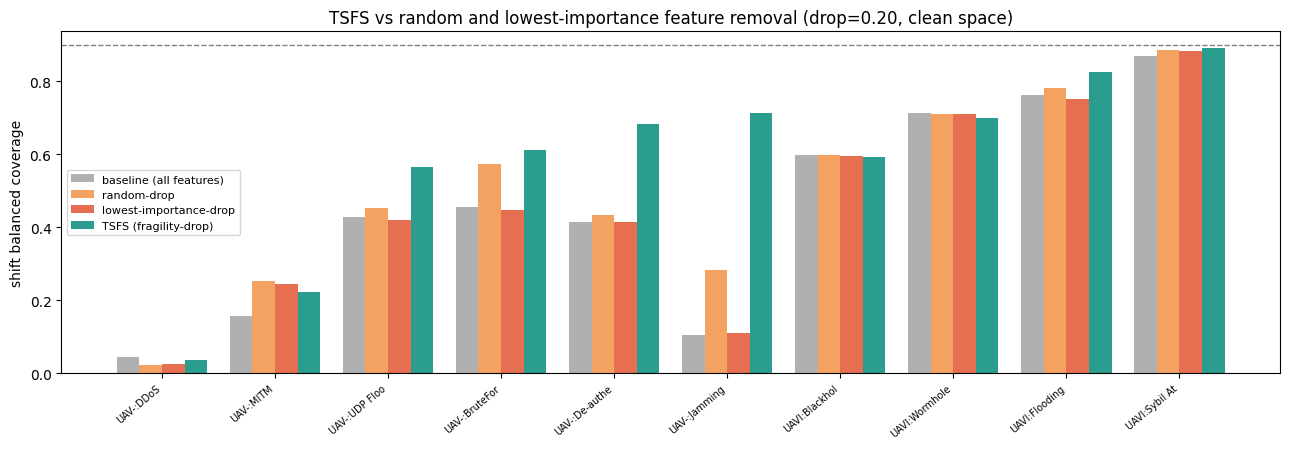

In [9]:
# FIGURE: TSFS vs the three alternatives, balanced coverage per family (clean space)
order=B.reset_index().sort_values(["dataset","cov_tsfs"])
fams=[f"{r.dataset[:4]}:{r.held_out[:8]}" for r in order.itertuples()]
x=np.arange(len(order)); w=0.2
fig,ax=plt.subplots(figsize=(13,4.6))
ax.bar(x-1.5*w,order["cov_baseline"],w,label="baseline (all features)",color="#b0b0b0")
ax.bar(x-0.5*w,order["cov_random"],w,label="random-drop",color="#f4a261")
ax.bar(x+0.5*w,order["cov_low_imp"],w,label="lowest-importance-drop",color="#e76f51")
ax.bar(x+1.5*w,order["cov_tsfs"],w,label="TSFS (fragility-drop)",color="#2a9d8f")
ax.axhline(0.90,ls="--",color="gray",lw=1)
ax.set_xticks(x); ax.set_xticklabels(fams,rotation=40,ha="right",fontsize=7)
ax.set_ylabel("shift balanced coverage"); ax.set_title("TSFS vs random and lowest-importance feature removal (drop=0.20, clean space)"); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(os.path.join(CFG["fig_dir"],"11_tsfs_baselines.png"),dpi=150,bbox_inches="tight"); plt.show()

In [10]:
# Commit
!git add reports/ figures/ notebooks/
!git commit -m "11 clean-space fragility (raw+norm, 10 seeds) + TSFS vs random/lowest-importance baselines (5 seeds); establishes the fragility criterion drives the coverage repair"
!git push origin main

[main 800533a] 11 clean-space fragility (raw+norm, 10 seeds) + TSFS vs random/lowest-importance baselines (5 seeds); establishes the fragility criterion drives the coverage repair
 7 files changed, 176 insertions(+), 1 deletion(-)
 create mode 100644 figures/11_tsfs_baselines.png
 create mode 100644 notebooks/11_fragility_tsfs_baselines.ipynb
 create mode 100644 reports/11_fragility_clean_agg.csv
 create mode 100644 reports/11_fragility_clean_raw.csv
 create mode 100644 reports/11_tsfs_vs_baselines_agg.csv
 create mode 100644 reports/11_tsfs_vs_baselines_raw.csv
Enumerating objects: 17, done.
Counting objects: 100% (17/17), done.
Delta compression using up to 2 threads
Compressing objects: 100% (12/12), done.
Writing objects: 100% (12/12), 169.16 KiB | 3.52 MiB/s, done.
Total 12 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/anasbiswas1/uav-trust-research.git
   7db4b98..800533a  main -> main
